# Example notebook for training, plotting and generation

In [1]:
import numpy as np
import torch
import os, platform
import sys
import matplotlib.pyplot as plt

## Training

In [2]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import quickread, compute_weights_large
from attention import trainer, trainerCondJ, trainer_PCA_comp_2_model, ar_trainer # choose trainer


# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path

'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src'

In [5]:
cwd = os.getcwd()
def save_tensor_to_txt(tensor, filename):
    with open(filename, 'w') as f:
        # Write tensor dimensions
        dims = tensor.size()
        f.write(" ".join(map(str, dims)) + "\n")

        # Iterate over the first dimension (slices)
        for i in range(dims[0]):
            f.write("\n")
            f.write(f"Slice {i + 1}\n")
            for j in range(dims[1]):  # Iterate over the second dimension (rows)
                row = tensor[i, j].tolist()
                f.write(",".join(map(str, row)) + "\n")

# if PCA:
n_comp_PCA=500
nb_bins_PCA=35
##
H = 64
d= 10
n_epochs = 250 #could go more down
#domain1_end = 63 #if your protein msa input family has a domain division, this is the zero index of the last aminoacid of the first domain
domain1_end = 62

older_dir = os.path.abspath(os.path.join(parent_dir, '..', '..'))
filename = os.path.join(older_dir, "DataAttentionDCA", "jdoms", "jdoms_bacteria_train2.fasta")
structfile = None
trainer_type = 'std' # 'std' or 'std_with_masks' 'multidomain'
family = 'jdoms'

if trainer_type == 'std':
    domain1_end = 0
    H1 = H2 = 0

if trainer_type == 'std' or trainer_type == 'std_with_masks':
    
    model = trainerCondJ(
        n_epochs=n_epochs,
        H=H,
        d=d,
        Nbins=nb_bins_PCA,
        Ncomp=n_comp_PCA,
        filename=filename,
        structfile=structfile,
        losstype='without_J',
        index_last_domain1=domain1_end,  # this value is the 0-index include the domain 1, for HK-RR is 63 (so 64 long domain 1) 
        #it is set to zero if i dont want to divide any domain
        H1 = H1,
        H2 = H2,
        max_gap_frac=0.8
    )

    # Create results directory
    simul_name = f'{H}_{d}_{family}_without_J_{n_epochs}_Jcond_PCA{n_comp_PCA}_Nbins{nb_bins_PCA}'
    results_dir = f'{parent_dir}/results/{simul_name}'
    os.makedirs(results_dir, exist_ok=True)

    # Save model parameters
    save_tensor_to_txt(model.Q.data, f"{results_dir}/Q_tensor.txt")
    save_tensor_to_txt(model.K.data, f"{results_dir}/K_tensor.txt")
    save_tensor_to_txt(model.V.data, f"{results_dir}/V_tensor.txt")

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.3712009523809523
Computed theta: 0.32758536641685554


100%|██████████| 14502/14502 [00:08<00:00, 1706.95it/s]


3265.70225762244
(563, 14502)
Using device: cpu
Epoch 1 - Train Loss: 973.9295, Val Loss: 429.0826
Epoch 2 - Train Loss: 547.7482, Val Loss: 259.2952
Epoch 3 - Train Loss: 385.3740, Val Loss: 183.6126
Epoch 4 - Train Loss: 308.3341, Val Loss: 143.2009
Epoch 5 - Train Loss: 264.6935, Val Loss: 118.7691
Epoch 6 - Train Loss: 236.5738, Val Loss: 102.6971
Epoch 7 - Train Loss: 217.2327, Val Loss: 91.3990
Epoch 8 - Train Loss: 202.8547, Val Loss: 82.9894
Epoch 9 - Train Loss: 191.8322, Val Loss: 76.5373
Epoch 10 - Train Loss: 183.0823, Val Loss: 71.2990
Epoch 11 - Train Loss: 175.7300, Val Loss: 66.9894
Epoch 12 - Train Loss: 169.5918, Val Loss: 63.3091
Epoch 13 - Train Loss: 164.3184, Val Loss: 60.1638
Epoch 14 - Train Loss: 159.7316, Val Loss: 57.3658
Epoch 15 - Train Loss: 155.5410, Val Loss: 54.8948
Epoch 16 - Train Loss: 151.9319, Val Loss: 52.7064
Epoch 17 - Train Loss: 148.6075, Val Loss: 50.7289
Epoch 18 - Train Loss: 145.6659, Val Loss: 48.8970
Epoch 19 - Train Loss: 142.9466, Val 

## Generation

### Load Q,K,V, calculate J

In [3]:
from seq_utils import read_tensor_from_txt, set_seed

In [4]:
"""
    Load Q, K, V matrices from jdoms (after training)
"""
set_seed()
H = 64
d= 10
N = 174
n_epochs = 250
nb_PCA_comp=2
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA35_cond/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA35_cond/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_PCA35_cond/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]


In [5]:
model=ModelPCAcondJ(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)

i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
# Mask only part without CPA
H, _, M = K_1.shape #(M=N+m)

W[:,:,:-2] = W[:,:,:-2] * mask
    
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)

torch.Size([64, 63, 65])
21
63
torch.Size([21, 56, 63, 65])


### Generate

In [6]:
from plm_model import SequencePLMvec, BatchSequencePLMvec

In [15]:
from tqdm import tqdm

def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for _ in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            site = site_selector(seq)        # custom site selection
        #seq.check_vectorized(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)

In [ ]:
generated_seqs = generate_plm(Jtens.cpu().numpy(), N_seqs=100000, beta=0.8, nb_PCA_comp=2, beta_pca=20, target_coords=np.array([24+21, 20+21]))

 56%|█████▌    | 55685/100000 [00:06<00:05, 8393.73it/s]

In [ ]:
#from plm_model import BatchSequencePLMvec
from tqdm import tqdm
def generate_plm_batch(J, Nseqs=1000, steps=2000, beta=1, beta_PCA=1):
    """
    Generate Nseqs sequences, each evolved for 'steps' iterations.
    Returns only the final sequence for each.
    """
    L = J.shape[2]  # sequence length
    print(L)
    sequences = [] #np.random.randint(21, size=(Nseqs, L))  # random initialization
    SeqBatch = BatchSequencePLMvec(J, Nseqs, beta=beta, nb_PCA_comp=2, PCA_component_list=np.array([24+21, 20+21]), beta_PCA=beta_PCA)
    for i in tqdm(range(steps)):
        site = np.random.randint(L)  # uniform random
        SeqBatch.draw_aa_batch(site)
        #SeqBatch.compare_draw(site)
        sequences.append(SeqBatch.get_sequences())
            #plm = BatchSequencePLMvec(J, Nseqs, beta=beta)        
        # compute PLM probabilities for all sequences at this site
        #probs = plm_site_distribution_batch_vec_full(sequences, J, site, beta)  # vectorized
        
        # vectorized sampling
        #cum_probs = np.cumsum(probs, axis=1)
        #r = np.random.rand(Nseqs)
        #sequences[:, site] = np.argmax(cum_probs >= r[:, None], axis=1)
    sequences = np.array(sequences[-1])  # return only the last sequences
    return sequences

gen_seqs_batch = generate_plm_batch(Jtens.cpu().numpy(), Nseqs=7000, steps=1500, beta=1, beta_PCA=50)
print(gen_seqs_batch.shape)

63


 10%|█         | 157/1500 [00:24<02:51,  7.84it/s]

## Plots

In [11]:
from seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, find_target_seq, sequences_from_fasta
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time

### Load train sequences

In [12]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37202728570888266
Computed theta: 0.3268577458459699


100%|██████████| 14502/14502 [00:08<00:00, 1792.35it/s]

3265.70225762244


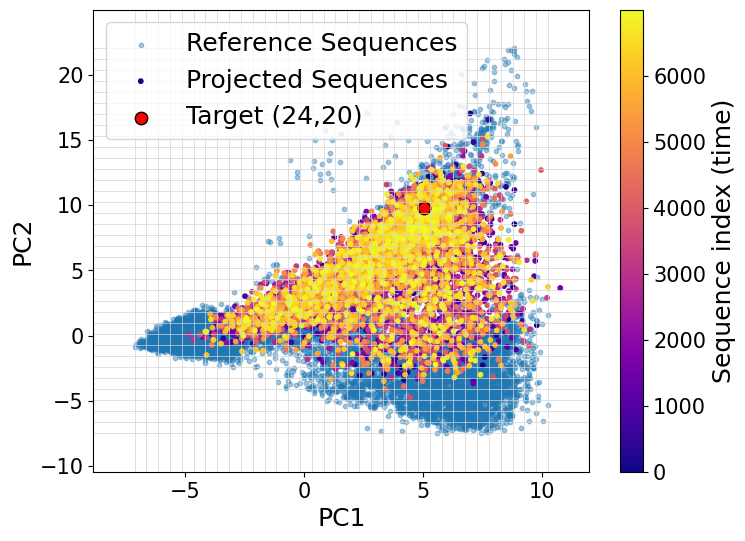

In [78]:
plot_projected_pca_time(Z.T,gen_seqs_batch[:,:-2], target_coords=np.array([24,20]), Nbins=35)

### Calculate frequencies

In [44]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

(21, 63)
Sampling 100000 pairs out of 24496500 total pairs.
Mean fraction of identical positions (sampled): 0.3394138781155823
Computed theta: 0.3582646669462082
θ = 0.3582646669462082 threshold = 22.0


 18%|█▊        | 1268/7000 [00:00<00:02, 2256.56it/s]

Processing sequence 1000/7000


 34%|███▎      | 2346/7000 [00:01<00:01, 2652.51it/s]

Processing sequence 2000/7000


...

Processing sequence 3000/7000


 67%|██████▋   | 4694/7000 [00:01<00:00, 4149.27it/s]

Processing sequence 4000/7000
Processing sequence 5000/7000


100%|██████████| 7000/7000 [00:01<00:00, 3837.95it/s]


Processing sequence 6000/7000
Processing sequence 7000/7000
M = 7000 N = 63 Meff = 6897.125
(21, 63)


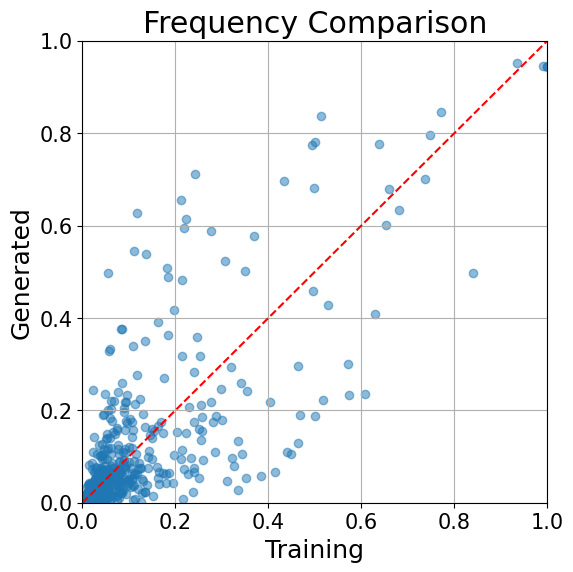

In [79]:
f_train = compute_empirical_freqs(Z, W, q=21)
f_train_flat = f_train.flatten()
print(f_train.shape)

W_gen,_ = compute_weights_large(gen_seqs_batch[:,:-2].T, theta='auto')

f_gen = compute_empirical_freqs(gen_seqs_batch[:,:-2].T, None,q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_train_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Training')
plt.ylabel('Generated')
plt.title('Frequency Comparison')
plt.plot([0, 1], [0, 1], 'r--')  # y=x line
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.show()